## Importing libraries

In [1]:
import magpylib as magpy
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import math

## Initial parameters

In [20]:
resolution=500    #number of points
R=100e-3           #in m
layers=2       
width=6e-3
diameter=1e-3      #diameter of individual wire

plotting=False
current=2          #in A

fig = go.Figure()

## Defining Helmholtz coil

In [23]:
def create_Helmholtz(R,layers,width,diameter,current,plotting):
    coils=[]
    coordinates=[]
    layer_current=current/layers
    turns_per_width=(width/diameter)
    
    
    for i in range (layers):
        
        
        theta =np.linspace(0,2*np.pi*turns_per_width,resolution)
        z=np.linspace(-width/2,width/2,resolution)
    
        
        lx=(R+i*diameter)*np.cos(theta)
        ly=(R+i*diameter)*np.sin(theta)
        lz=z
    
        layer_coordinates=np.stack((lx,ly,lz),axis=1)
        
        layer_coil=magpy.current.Polyline(current=layer_current,vertices=layer_coordinates)
        coils.append(layer_coil)
        coordinates.append(layer_coordinates)
        
        
    coordinates = np.vstack(coordinates)
    
    coil1=magpy.Collection(coils)
    coil1.position = (0, 0, R/2)
    coil2 = coil1.copy(position=(0, 0, -R/2))
    
    
    coil1_coordinates=coordinates+[0,0,R/2]
    coil2_coordinates=coordinates-[0,0,R/2]
    
    total_coordinates=np.vstack((coil1_coordinates,coil2_coordinates))
    
    
    
    
    Helmholtz = magpy.Collection(coil1, coil2)
    
    if plotting==True:
        Helmholtz.show(renderer="browser")

    return coil2, total_coordinates


## Cost function

In [10]:
def cost_function(mags,roi): #ratio of the radius)

    roi_grid=np.mgrid[-roi*R:roi*R:10j, -roi*R:roi*R:10j, -roi*R:roi*R:10j].T
    

    r = np.linalg.norm(roi_grid, axis=-1)
    mask = r <= roi*R

    sphere_points = roi_grid[mask]
    
    B_roi=mags.getB(sphere_points)
    
    magnitude_B=np.linalg.norm(B_roi,axis=-1)
    
    mean_B=np.mean(magnitude_B)
    
    B_max=magnitude_B.max()
    B_min=magnitude_B.min()
    eta=((B_max-B_min)/mean_B)*1e6
    
    return eta, mean_B*1000, sphere_points


## Visualize in 3D

In [11]:
def visualize_3d(grid,mags):    #grid to be (N,N,N,3)
    sens = magpy.Sensor(pixel=grid)

    # hide axes arrows
    sens.style.arrows.x.show = False
    sens.style.arrows.y.show = False
    sens.style.arrows.z.show = False
    
    # control size
    sens.style.size = 2
    
    # pixel field settings
    sens.style.pixel.field.source = "B"
    sens.style.pixel.field.sizescaling = "linear"
    sens.style.pixel.field.colormap = "Inferno"
    sens.style.pixel.field.colorscaling = "linear"
    sens.style.pixel.field.symbol = "arrow3d"
    
    
    fig = magpy.show([sens, mags], backend="plotly", return_fig=True)
    fig.show(renderer="browser")

## Creating a coil

In [24]:
coil2,coordinates=create_Helmholtz(R,layers, width,diameter,current,plotting)  #coils is a mags object
roi=0.125
grid_3D=np.mgrid[-R*2:R*2:10j, -R*2:R*2:10j, -R*2:R*2:10j].T
eta,mean_B,sphere_points=cost_function(coil2,roi)

## Results

In [13]:
visualize_3d(grid_3D,Helmholtz)

print('For Helmholtz','\n')
print(f'homogeneity ',eta,'\n')
print(f'field (mT) ',mean_B,'\n')


For Helmholtz 

homogeneity  231233.30303064812 

field (mT)  0.053910014067232455 



## Visualize in 2D

In [14]:
def visualize_2D(grid,mags,plane,i):     
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    
    X,Y,Z=grid.T
    X=X[:,0,0]
    Y=Y[0,:,0]
    Z=Z[0,0,:]

    if plane == 'xy':
        grid=grid[:,:,:,i]
        B = mags.getB(grid)
        B0 = mags.getB((0, 0, 0))
        B0amp = np.linalg.norm(B0)
        
        err = np.linalg.norm((B-B0)/B0amp, axis=2)
        sp = ax.contourf(X, Y, err*100)
        # Figure styling
        ax.set(
            title=f'% Variation from field at origin in XY plane at slice, {i} ',
            xlabel='x-position (m)',
            ylabel='y-position (m)',
            aspect=1,
        )
    if plane == 'xz':
        grid=grid[:,:,i,:]
        B = mags.getB(grid)
        B0 = mags.getB((0, 0, 0))
        B0amp = np.linalg.norm(B0)
        
        err = np.linalg.norm((B-B0)/B0amp, axis=2)
        sp = ax.contourf(X, Z, err*100)
        # Figure styling
        ax.set(
            title=f'% Variation from field at origin in XZ plane at slice, {i} ',
            xlabel='x-position (m)',
            ylabel='z-position (m)',
            aspect=1,
        )
    if plane == 'yz':
        grid=grid[:,i,:,:]
        B = mags.getB(grid)
        B0 = mags.getB((0, 0, 0))
        B0amp = np.linalg.norm(B0)
        
        err = np.linalg.norm((B-B0)/B0amp, axis=2)
        sp = ax.contourf(Y, Z, err*100)
        # Figure styling
        ax.set(
            title=f'% Variation from field at origin in YZ plane at slice, {i} ',
            xlabel='y-position (m)',
            ylabel='z-position (m)',
            aspect=1,
        )
    

    #uniformity
    
    plt.colorbar(sp, ax=ax, label='(% of B0)')
    plt.show()

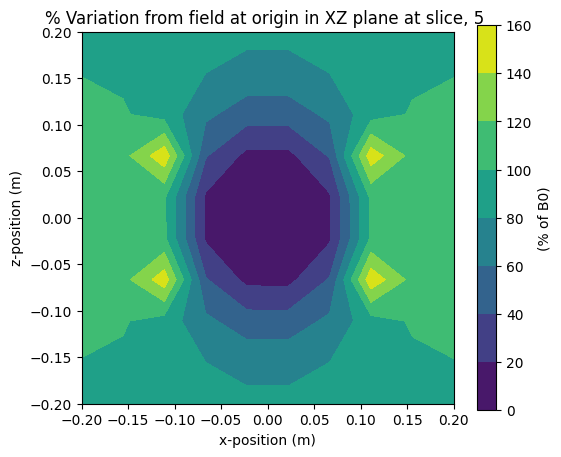

In [15]:
visualize_2D(grid_3D,Helmholtz,'xz',5)

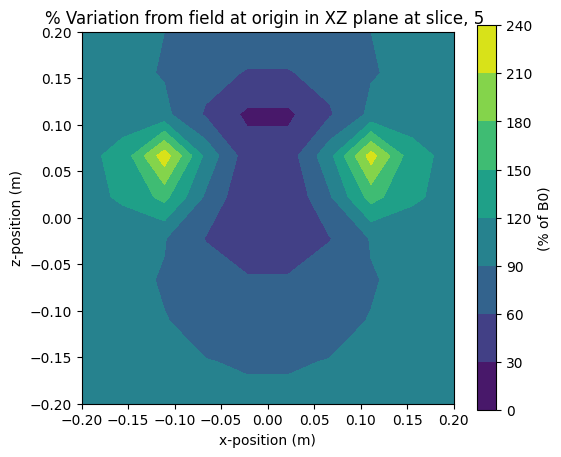

In [22]:
visualize_2D(grid_3D,coil1,'xz',5)

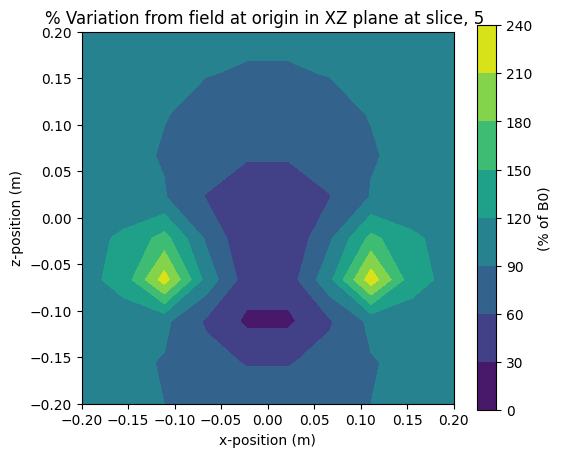

In [25]:
visualize_2D(grid_3D,coil2,'xz',5)